# Quickstart guide
This notebook demonstrates how to use the processing scripts to clean and process competition submissions.

All the logs are saved in the ```logs/``` folder. You can check them when necessary.

## Import

In [55]:
import sys 
sys.path.append('../')

from processing.clean_submissions import clean_all_submissions, clean_submission
from processing.process_windows import process_windows
from evaluation.evaluate_submissions import evaluate_all_submissions, evaluate_submission

from pathlib import Path
import pandas as pd

In [6]:
repo_dir = Path.home() / 'prediction_competition_2023'
data_dir = repo_dir / 'data'
raw_data_dir = data_dir / 'raw'
cleaned_data_dir = data_dir / 'cleaned'
processed_data_dir = data_dir / 'processed'

## Clean submissions

In [5]:
clean_all_submissions(
    submissions=raw_data_dir / 'final_submissions/',
    save_to=cleaned_data_dir / 'final_submissions_cleaned_May19/',
    targets=['cm', 'pgm'],
    windows=['Y2018', 'Y2019', 'Y2020', 'Y2021', 'Y2022', 'Y2023', 'Y2024'],
)

Cleaning submissions:   0%|          | 0/23 [00:00<?, ?it/s]

Cleaning submissions: 100%|██████████| 23/23 [50:05<00:00, 130.69s/it] 


In [3]:
clean_all_submissions(
    submissions=raw_data_dir / 'benchmarks/',
    save_to=cleaned_data_dir / 'benchmarks_cleaned_May20/',
    targets=['cm', 'pgm'],
    windows=['Y2018', 'Y2019', 'Y2020', 'Y2021', 'Y2022', 'Y2023', 'Y2024'],
)

Cleaning submissions:   0%|          | 0/5 [00:00<?, ?it/s]

Cleaning submissions: 100%|██████████| 5/5 [28:50<00:00, 346.18s/it]


## Separate the window
There is no window for 2025 in the submission, i.e., the predictions from Jan 2025 to June 2025 are also categorized as window=2024. We need to manually create a window=2025 to move forward.

In [3]:
process_windows(
    submissions=cleaned_data_dir / 'final_submissions_cleaned_May19/',
    save_to=processed_data_dir / 'final_submissions_processed_May19/'
)

Processing:   0%|          | 0/398 [00:00<?, ?it/s]

Processing: 100%|██████████| 398/398 [02:33<00:00,  2.59it/s]


In [3]:
process_windows(
    submissions=cleaned_data_dir / 'benchmarks_cleaned_May19/',
    save_to=processed_data_dir / 'benchmarks_processed_May19/'
)

Processing: 100%|██████████| 150/150 [01:37<00:00,  1.53it/s]


In [5]:
process_windows(
    submissions=raw_data_dir / 'actuals/',
    save_to=processed_data_dir / 'actuals_processed_May19/'
)

Processing: 100%|██████████| 32/32 [00:00<00:00, 567.28it/s]


## Generate evaluation
Note that the evaluation is saved to the same folder as ```submissions```

The evaluation folder is used to save evaluations for the dashboard as requested by Henrik.

In [ ]:
evaluate_all_submissions(
    submissions=processed_data_dir / 'final_submissions_processed_May19/',
    actuals=raw_data_dir / 'actuals/',
    targets=['cm', 'pgm'],
    windows=['Y2018', 'Y2019', 'Y2020', 'Y2021', 'Y2022', 'Y2023', 'Y2024', 'Y2025'],
)


Evaluating submissions:   0%|          | 0/23 [00:00<?, ?it/s]

Evaluating submissions:  91%|█████████▏| 21/23 [2:06:39<12:32, 376.41s/it]  

## Plot

In [90]:
import importlib
from plotting import plot
importlib.reload(plot)
from plotting.plot import choropleth_map_forecast, choropleth_map_evaluation

### By month

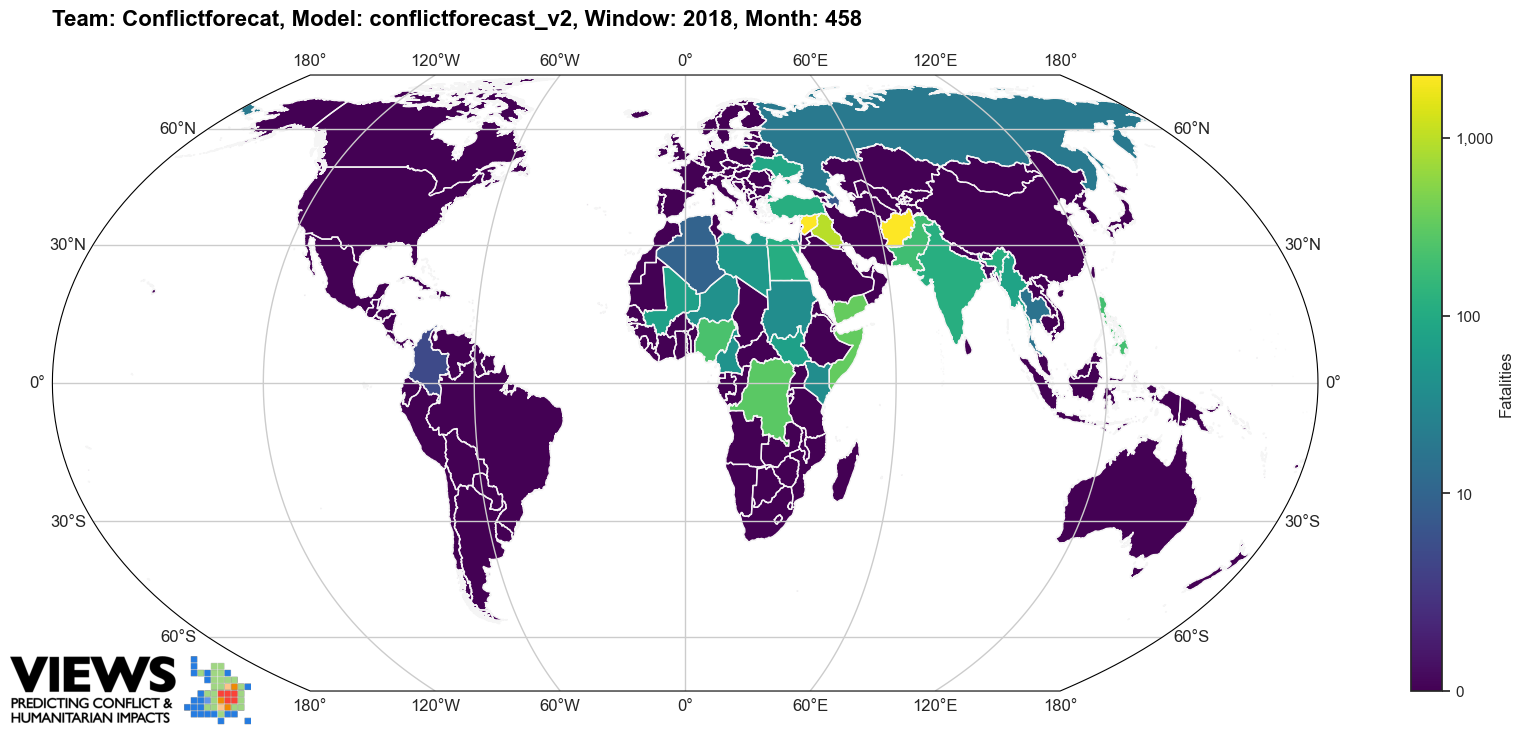

In [51]:
choropleth_map_forecast(submission=processed_data_dir/'final_submissions_processed_May19/conflictforecast_v2', target='cm', window='2018', month=458)

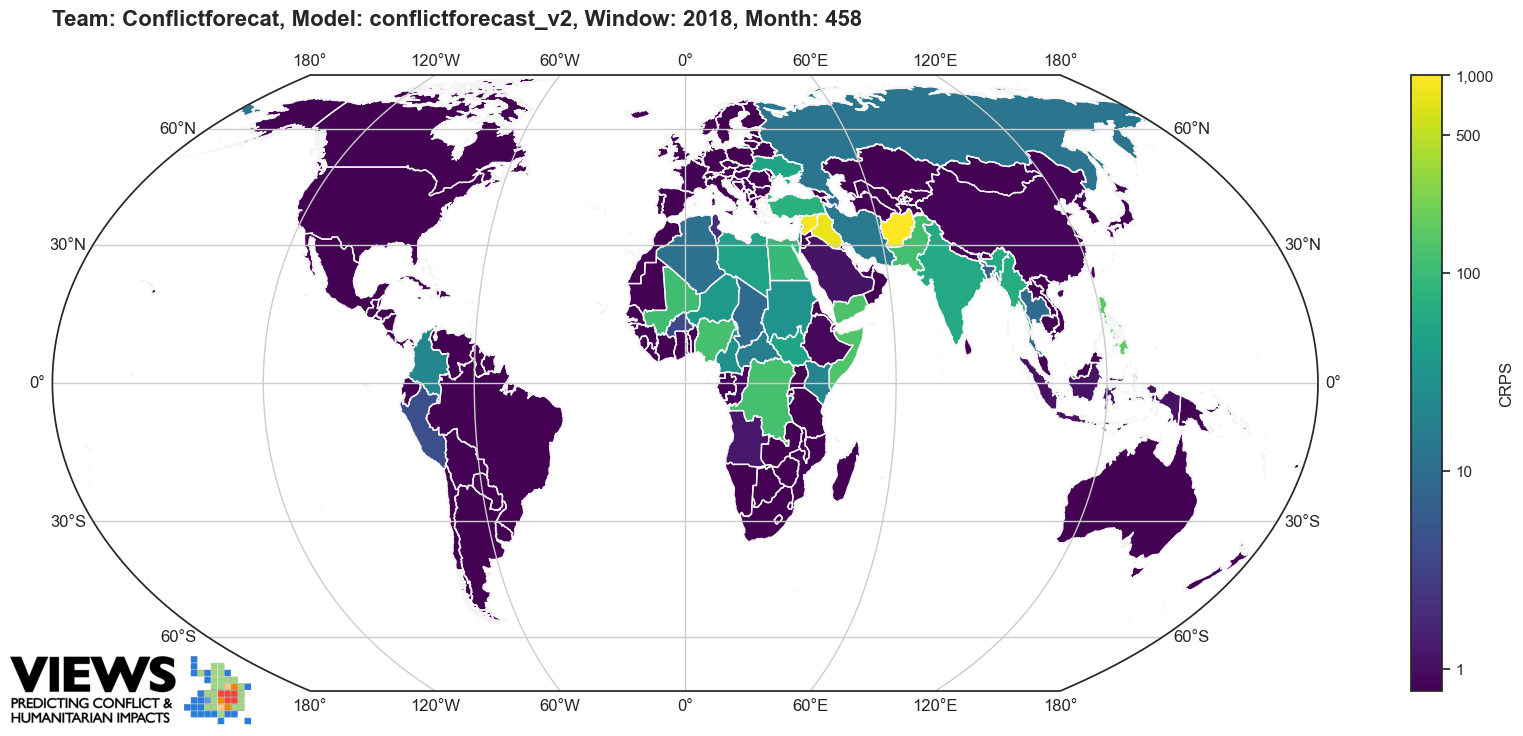

In [91]:
choropleth_map_evaluation(submission=processed_data_dir/'final_submissions_processed_May19/conflictforecast_v2', metric='crps', target='cm', window='2018', month=458)

### By year

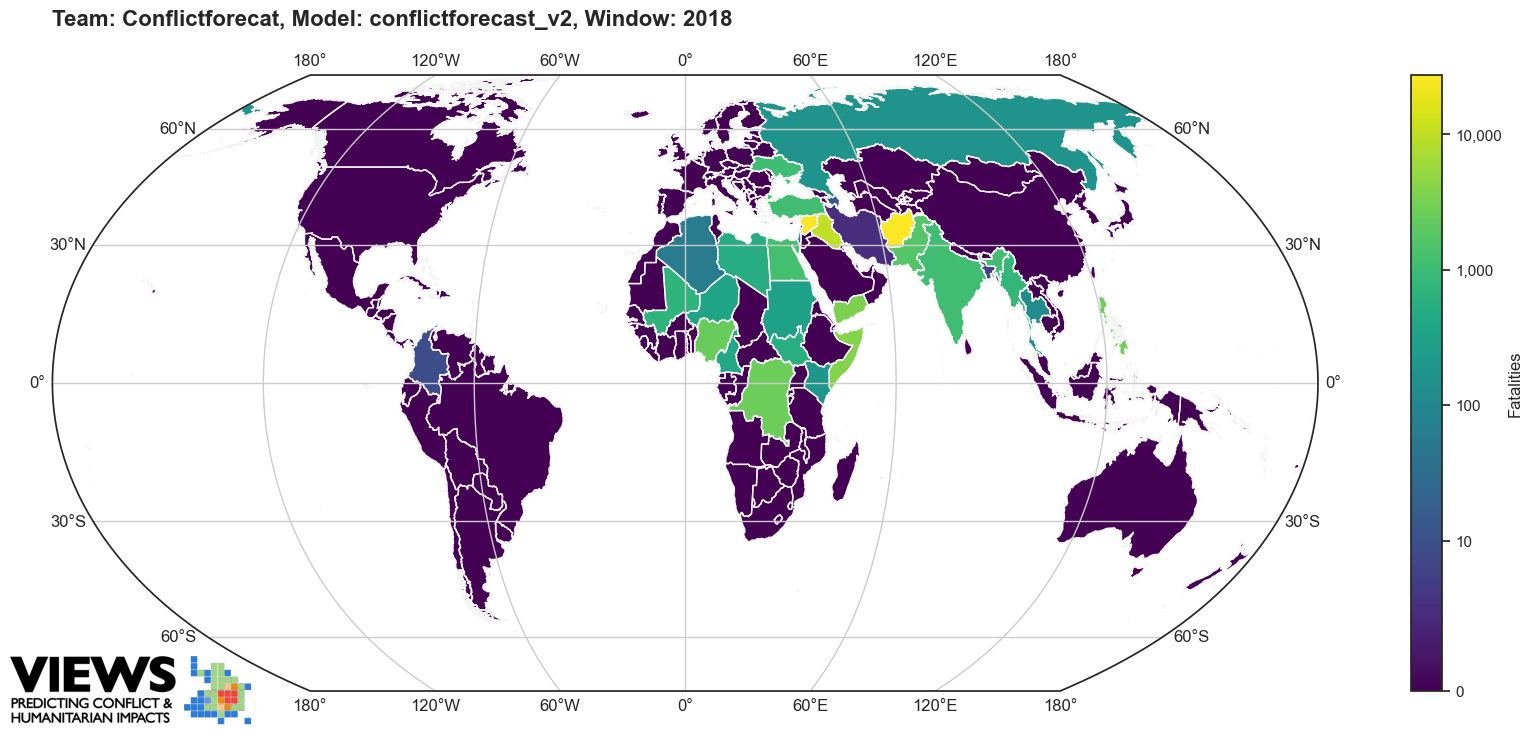

In [73]:
choropleth_map_forecast(submission=processed_data_dir/'final_submissions_processed_May19/conflictforecast_v2', target='cm', window='2018')

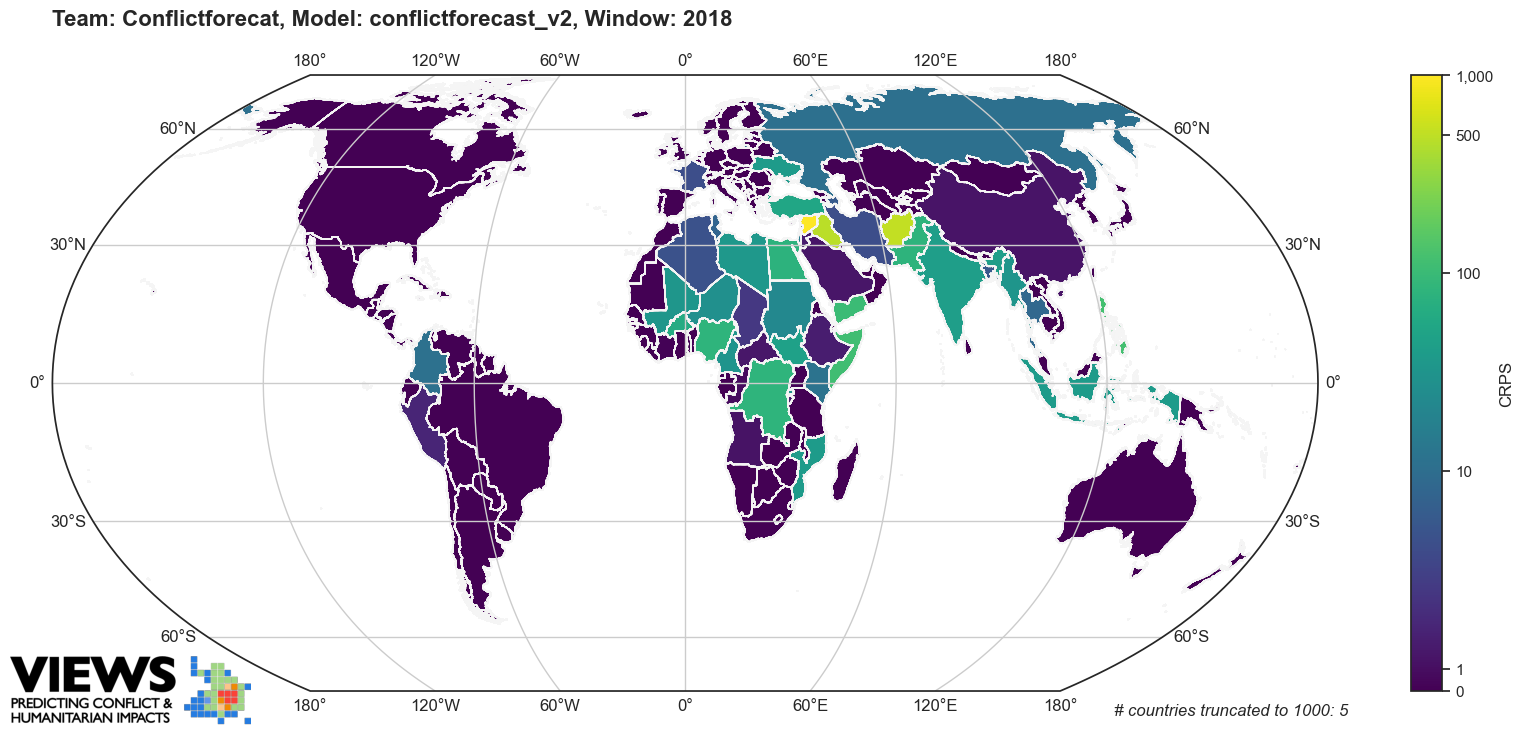

In [44]:
choropleth_map_evaluation(submission=processed_data_dir/'final_submissions_processed_May19/conflictforecast_v2', metric='crps', target='cm', window='2018')

## Analyze the result

In [41]:
import importlib
from evaluation import analyze_performance
importlib.reload(analyze_performance)
from evaluation.analyze_performance import analyze_all_models, analyze_single_model, print_analysis

In [7]:
result = analyze_single_model(submission=processed_data_dir/'final_submissions_processed_May19/conflictforecast_v2', target='cm', window='Y2018')

In [53]:
print_analysis(result, metric='crps', month=458)


Model: conflictforecast_v2
--------------------------------------------------

CRPS Analysis:
------------------------------

Worst performing predictions by month:
Month  Unit  Value
--------------------
   458   133    571.2121
   458   220    505.8212
   458    60    420.1461
   458   145     59.5883
   458   120     49.4631
   458   124     45.5081
   458    79     40.9945
   458   167     40.9848
   458   136     40.5108
   458    50     36.8020

Best performing predictions by month:
Month  Unit  Value
--------------------
   458     5      0.0000
   458   180      0.0000
   458   163      0.0000
   458   161      0.0000
   458    24      0.0000
   458    34      0.0000
   458    63      0.0000
   458    26      0.0000
   458   116      0.0000
   458   127      0.0000



In [85]:
df_crps = pd.read_parquet(processed_data_dir/'final_submissions_processed_May19/conflictforecast_v2/eval/cm/window=Y2018/metric=crps/crps.parquet')

In [86]:
df_crps

value
month_id country_id           
457      1            0.000004
         2            0.000004
         3            0.000007
         4            0.000027
         5            0.000001
...                        ...
468      242          0.000051
         243          0.000317
         244          0.010205
         245          6.459909
         246         16.663325

[2292 rows x 1 columns]

In [87]:
df_crps.groupby(by="country_id").sum()

,value
country_id,
1,0.000143
2,0.000163
3,0.000216
4,0.000268
5,0.000103
...,...
242,0.000215
243,0.001104
244,0.027867
